In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os


In [3]:
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32
EPOCHS = 60

In [4]:
train_path = './data/train'
test_path = './data/test'

In [5]:
train_datagen = ImageDataGenerator(
    rescale = 1.0/255,
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    horizontal_flip = True,
    zoom_range = 0.2,
    validation_split = 0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    subset = 'training'
)

Found 1280 images belonging to 2 classes.


In [6]:
train_generator.class_indices

{'cat': 0, 'dog': 1}

In [7]:
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    subset = 'validation'
)


Found 320 images belonging to 2 classes.


In [8]:
test_datagen = ImageDataGenerator(
    rescale=1.0/255
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 400 images belonging to 2 classes.


In [9]:
model = Sequential([
    layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3), activation = 'relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3), activation = 'relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation = 'relu'),
    layers.Dense(2, activation = 'softmax')
])

d:\Annaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,690 (72.61 MB)

 Trainable params: 19,034,690 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer = 'adam', 
    loss = 'categorical_crossentropy', 
    metrics = ['accuracy'])

In [20]:
history = model.fit(train_generator, epochs = EPOCHS, validation_data = validation_generator)

Epoch 1/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 649ms/step - accuracy: 0.4922 - loss: 0.8270 - val_accuracy: 0.5250 - val_loss: 0.6908
Epoch 2/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 640ms/step - accuracy: 0.5430 - loss: 0.6880 - val_accuracy: 0.5781 - val_loss: 0.6903
Epoch 3/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 693ms/step - accuracy: 0.5469 - loss: 0.6795 - val_accuracy: 0.5594 - val_loss: 0.7064
Epoch 4/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 689ms/step - accuracy: 0.5570 - loss: 0.6830 - val_accuracy: 0.5656 - val_loss: 0.6886
Epoch 5/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 706ms/step - accuracy: 0.5305 - loss: 0.6860 - val_accuracy: 0.5813 - val_loss: 0.6808
Epoch 6/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 698ms/step - accuracy: 0.5562 - loss: 0.6831 - val_accuracy: 0.5938 - val_loss: 0.6859
Epoch 7/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 692ms/step - accuracy: 0.5641 - loss: 0.6761 - val_accuracy: 0.5594 - val_loss: 0.6924
Epoch 8/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 729ms/step - accuracy: 0.5703 - loss: 0.6779 - val_accu

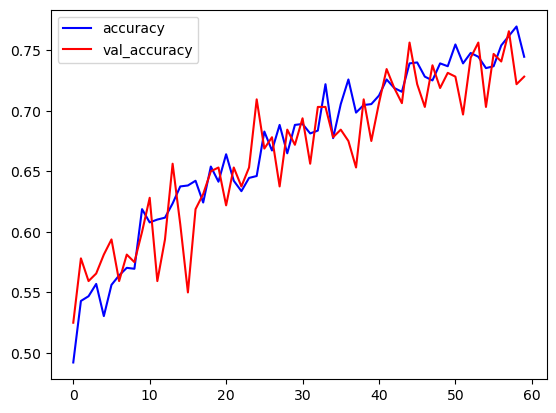

In [21]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color = 'blue', label = 'accuracy')
plt.plot(history.history['val_accuracy'], color = 'red', label = 'val_accuracy')
plt.legend()
plt.show()

In [22]:
model.evaluate(test_generator)

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 360ms/step - accuracy: 0.7225 - loss: 0.5410


[0.5410354137420654, 0.7225000262260437]

In [23]:
model.save('cat_dog_classifier.keras')